# Maternal Health Risk Prediction - Model Training & Evaluation

## Project Overview

This notebook focuses on the machine learning phase of the maternal health risk prediction project.

The primary objective is to build and evaluate classification models capable of predicting maternal health risk levels using medical and physiological indicators.

The workflow includes:

- data preprocessing
- feature preparation
- train-test splitting
- feature scaling
- machine learning model training
- model evaluation
- performance comparison
- final model selection

The project aims to identify patterns associated with maternal health risks and support early medical risk assessment through predictive analytics.

---

## Machine Learning Objectives

The goals of this notebook are:

- prepare the dataset for machine learning
- train multiple classification algorithms
- compare model performance
- evaluate classification effectiveness
- identify the most suitable predictive model

---

## Models Planned

The following classification algorithms will be explored:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

---

## Evaluation Metrics

Model performance will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- ROC-AUC Score
- Cross Validation

---

## Expected Outcome

At the end of this notebook:

- the best-performing model will be identified
- important predictive features will be analyzed
- preprocessing effectiveness will be evaluated
- conclusions regarding maternal health risk prediction will be presented

In [953]:
# ============================================
# IMPORT LIBRARIES
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Cross Validation
from sklearn.model_selection import cross_val_score

# Statistical visualization settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


# Dataset Loading

Before training machine learning models, the dataset must be loaded and inspected.

This section:

- loads the dataset
- verifies successful loading
- checks dataset dimensions
- previews the data structure

Ensuring correct dataset loading is critical before preprocessing and model training.

In [954]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv("../data/Dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [955]:
# ============================================
# DATASET SHAPE
# ============================================

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(1205, 12)


In [956]:
# ============================================
# FIRST 5 ROWS
# ============================================

df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [957]:
# ============================================
# DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


# Initial Dataset Observations

The dataset appears suitable for supervised machine learning classification tasks.

Key observations:

- the dataset contains numerical medical indicators
- the target variable is categorical
- several variables contain missing values
- preprocessing will be required before model training
- feature scaling may improve certain algorithms

The next section focuses on preprocessing and preparing the dataset for machine learning.

# Preprocessing Strategy & Modeling Preparation

Machine learning models require properly prepared and cleaned data before training.

Raw datasets often contain:

- missing values
- categorical variables
- inconsistent scales
- noisy observations

Without preprocessing, model performance may decrease significantly.

---

## Preprocessing Objectives

This section focuses on:

- handling missing values
- encoding categorical variables
- separating features and target variables
- preparing data for machine learning algorithms
- scaling numerical features when necessary

---

## Planned Preprocessing Steps

The preprocessing workflow will include:

1. handling missing values
2. encoding the target variable
3. separating features and labels
4. train-test splitting
5. feature scaling

These steps help ensure:

- fair model evaluation
- improved learning performance
- algorithm compatibility
- reduced bias and instability

In [958]:
# ============================================
# MISSING VALUE OVERVIEW
# ============================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Systolic BP                5
Diastolic                  4
BS                         2
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Heart Rate                 2
Risk Level                18
dtype: int64

# Missing Value Handling Strategy

Several variables contain missing observations.

The percentage of missing data is relatively low across the dataset.

Therefore:

- removing all rows may unnecessarily reduce dataset size
- statistical imputation is more appropriate

---

## Selected Imputation Strategy

Different imputation strategies may be used depending on feature characteristics.

For numerical medical variables:

- median imputation is preferred
- median is more robust against outliers

For categorical variables:

- mode imputation is appropriate

This approach helps preserve dataset integrity while minimizing information loss.

In [959]:
# ============================================
# HANDLE NUMERICAL MISSING VALUES
# ============================================

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

print("Numerical missing values handled successfully.")

Numerical missing values handled successfully.


In [960]:
# ============================================
# HANDLE TARGET VARIABLE MISSING VALUES
# ============================================

df["Risk Level"] = df["Risk Level"].fillna(
    df["Risk Level"].mode()[0]
)

print("Target variable missing values handled successfully.")

Target variable missing values handled successfully.


In [961]:
# ============================================
# VERIFY REMAINING MISSING VALUES
# ============================================

df.isnull().sum()

Age                       0
Systolic BP               0
Diastolic                 0
BS                        0
Body Temp                 0
BMI                       0
Previous Complications    0
Preexisting Diabetes      0
Gestational Diabetes      0
Mental Health             0
Heart Rate                0
Risk Level                0
dtype: int64

# Observations After Missing Value Handling

After preprocessing:

- missing values were successfully handled
- the dataset became fully usable for machine learning
- numerical features were preserved without excessive row removal
- statistical consistency was maintained using median imputation

The dataset is now ready for categorical encoding and feature preparation.

# Target Variable Encoding

Machine learning algorithms require numerical target labels.

Currently, the target variable contains categorical values:

- High
- Low

These categories must be transformed into numerical representations before model training.

Label encoding converts:

- High → 0
- Low → 1

This transformation allows classification algorithms to process the target variable correctly.

In [962]:
# ============================================
# LABEL ENCODING
# ============================================

label_encoder = LabelEncoder()

df["Risk Level"] = label_encoder.fit_transform(
    df["Risk Level"]
)

print("Target variable encoded successfully.")

Target variable encoded successfully.


In [963]:
# ============================================
# ENCODED TARGET VARIABLE
# ============================================

df["Risk Level"].value_counts()

Risk Level
1    731
0    474
Name: count, dtype: int64

# Feature and Target Separation

Machine learning models learn patterns by analyzing:

- input variables (features)
- output variables (target labels)

The dataset must therefore be separated into:

- X → feature matrix
- y → target vector

---

## Feature Variables

The feature matrix contains medical and physiological measurements such as:

- blood pressure
- blood sugar
- BMI
- heart rate
- diabetes indicators

These variables are used by machine learning algorithms to identify maternal health risk patterns.

---

## Target Variable

The target variable represents the maternal health risk category.

After encoding:

- 0 → High Risk
- 1 → Low Risk

The next step is separating these variables for model training.

In [964]:
# ============================================
# FEATURE / TARGET SEPARATION
# ============================================

X = df.drop("Risk Level", axis=1)

y = df["Risk Level"]

print("Features and target variable separated successfully.")

Features and target variable separated successfully.


In [965]:
# ============================================
# FEATURE MATRIX SHAPE
# ============================================

print("Feature Matrix Shape:")
print(X.shape)

Feature Matrix Shape:
(1205, 11)


In [966]:
# ============================================
# TARGET VECTOR SHAPE
# ============================================

print("Target Vector Shape:")
print(y.shape)

Target Vector Shape:
(1205,)


# Train-Test Split

Machine learning models must be evaluated on unseen data.

If models are trained and tested using the same data:

- evaluation results become unreliable
- overfitting risk increases
- generalization ability cannot be measured properly

---

## Dataset Splitting Strategy

The dataset will be divided into:

- training data
- testing data

The training set is used to:

- learn patterns
- optimize model parameters

The testing set is used to:

- evaluate model performance
- estimate real-world predictive capability

---

## Selected Split Ratio

This project uses:

- 80% training data
- 20% testing data

This ratio is commonly used in machine learning applications because it provides:

- sufficient training information
- reliable testing evaluation

In [967]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")

Train-test split completed successfully.


In [968]:
# ============================================
# TRAINING SET SHAPES
# ============================================

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

X_train Shape: (964, 11)
y_train Shape: (964,)


# Observations After Dataset Splitting

The dataset was successfully divided into training and testing subsets.

Key observations:

- the majority of data is reserved for training
- sufficient unseen data remains for evaluation
- stratified splitting preserves class distribution balance
- the dataset is now ready for feature scaling and model training

The next step focuses on feature scaling and normalization.

# Feature Scaling

Machine learning algorithms may become sensitive to differences in feature magnitudes.

For example:

- blood pressure values may range around 100–140
- BMI values may range around 20–35
- diabetes indicators may contain binary values such as 0 and 1

Without scaling:

- large-scale variables may dominate model learning
- distance-based algorithms may become biased
- optimization performance may decrease

---

## Why Scaling is Important

Feature scaling helps:

- normalize feature magnitudes
- improve convergence speed
- enhance numerical stability
- improve distance calculations

Scaling is especially important for:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)

---

## Selected Scaling Technique

This project uses:

# StandardScaler

Standardization transforms variables into distributions with:

- mean = 0
- standard deviation = 1

This allows machine learning algorithms to treat features more fairly.

In [969]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [970]:
# ============================================
# SCALED TRAINING DATA SHAPE
# ============================================

print("Scaled X_train Shape:")
print(X_train_scaled.shape)

Scaled X_train Shape:
(964, 11)


In [971]:
# ============================================
# SCALED TEST DATA SHAPE
# ============================================

print("Scaled X_test Shape:")
print(X_test_scaled.shape)

Scaled X_test Shape:
(241, 11)


In [972]:
# ============================================
# SCALED FEATURE PREVIEW
# ============================================

scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

scaled_df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
0,-0.154261,-1.671108,-1.169913,-0.487912,2.335618,-0.471493,-0.451105,-0.634982,-0.366221,-0.696679,-0.804763
1,1.602997,0.179402,0.209317,-0.158713,-0.373811,-0.602327,-0.451105,-0.634982,-0.366221,-0.696679,-0.804763
2,-0.923062,0.179402,-1.169913,-1.143020,-0.373811,-0.863996,-0.451105,1.574847,-0.366221,-0.696679,-0.528435
3,-0.923062,1.236836,0.898931,-0.191633,-0.373811,0.836852,-0.451105,-0.634982,-0.366221,1.435381,1.682192
4,0.285053,1.236836,1.243739,-0.158713,-0.373811,-0.863996,-0.451105,-0.634982,-0.366221,-0.696679,-0.252107


# Observations After Feature Scaling

After standardization:

- features are centered around zero
- feature variances become normalized
- numerical dominance between variables is reduced
- machine learning algorithms can learn more efficiently

The dataset is now fully prepared for machine learning model training.

# Logistic Regression Model

Logistic Regression is one of the most fundamental classification algorithms in machine learning.

It predicts probabilities using a logistic (sigmoid) function and performs binary classification.

---

## Why Logistic Regression?

This algorithm is:

- simple
- interpretable
- computationally efficient
- widely used in medical prediction systems

It performs especially well when:

- relationships are approximately linear
- features are scaled properly
- classes are separable

---

## Goal

The objective is to classify pregnancy risk levels:

- Low Risk → 0
- High Risk → 1

using medical indicators such as:

- blood pressure
- blood sugar
- BMI
- complications
- diabetes history
- heart rate

---

## Model Training Workflow

The workflow includes:

1. model creation
2. model training
3. prediction generation
4. performance evaluation
5. confusion matrix analysis
6. classification report interpretation

In [973]:
# ============================================
# IMPORT LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

In [974]:
# ============================================
# CREATE LOGISTIC REGRESSION MODEL
# ============================================

log_model = LogisticRegression(
    random_state=42
)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [975]:
# ============================================
# TRAIN LOGISTIC REGRESSION MODEL
# ============================================

log_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [976]:
# ============================================
# GENERATE PREDICTIONS
# ============================================

y_pred_log = log_model.predict(
    X_test_scaled
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [977]:
# ============================================
# PREDICTION PREVIEW
# ============================================

print("First 20 Predictions:")
print(y_pred_log[:20])

First 20 Predictions:
[0 1 0 0 0 1 0 1 1 0 1 0 1 1 0 1 1 0 1 0]


In [978]:
# ============================================
# ACTUAL VALUES PREVIEW
# ============================================

print("First 20 Actual Values:")
print(y_test.values[:20])

First 20 Actual Values:
[0 1 0 0 0 1 0 1 1 0 1 0 1 1 0 1 1 0 0 0]


In [979]:
# ============================================
# IMPORT EVALUATION METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [980]:
# ============================================
# CALCULATE ACCURACY
# ============================================

log_accuracy = accuracy_score(
    y_test,
    y_pred_log
)

print("Logistic Regression Accuracy:")
print(log_accuracy)

Logistic Regression Accuracy:
0.9543568464730291


In [981]:
# ============================================
# ACCURACY PERCENTAGE
# ============================================

print(
    f"Accuracy Percentage: {log_accuracy * 100:.2f}%"
)

Accuracy Percentage: 95.44%


In [982]:
# ============================================
# GENERATE CONFUSION MATRIX
# ============================================

log_cm = confusion_matrix(
    y_test,
    y_pred_log
)

print("Confusion Matrix:")
print(log_cm)

Confusion Matrix:
[[ 90   5]
 [  6 140]]


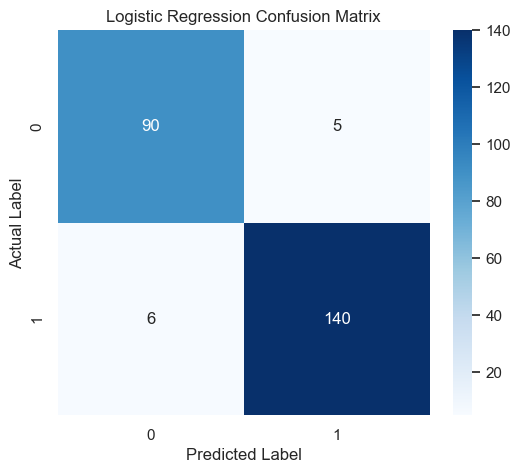

In [983]:
# ============================================
# CONFUSION MATRIX HEATMAP
# ============================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    log_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [984]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

log_report = classification_report(
    y_test,
    y_pred_log
)

print(log_report)

              precision    recall  f1-score   support

           0       0.94      0.95      0.94        95
           1       0.97      0.96      0.96       146

    accuracy                           0.95       241
   macro avg       0.95      0.95      0.95       241
weighted avg       0.95      0.95      0.95       241



# Logistic Regression Evaluation Observations

The Logistic Regression model achieved very strong classification performance.

---

## Accuracy

The model reached:

- 95.44% accuracy

which indicates that the majority of pregnancy risk cases were classified correctly.

---

## Confusion Matrix Analysis

The confusion matrix showed:

- 90 correct Low Risk predictions
- 140 correct High Risk predictions
- only 5 false positives
- only 6 false negatives

This indicates that the model generalized very well on unseen test data.

---

## Precision and Recall

The model achieved high precision and recall values for both classes.

Especially for the High Risk class:

- Precision = 0.97
- Recall = 0.96
- F1-score = 0.96

This is highly important in medical classification problems because detecting high-risk pregnancies accurately is critical.

---

## Overall Interpretation

The Logistic Regression model demonstrated:

- excellent predictive capability
- strong class separation
- balanced classification performance
- reliable medical risk prediction behavior

The model can be considered a strong baseline classifier for this dataset.

# K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a distance-based machine learning classification algorithm.

It classifies new observations according to the labels of the nearest neighboring data points.

---

## How KNN Works

The algorithm:

1. calculates distances between samples
2. finds the nearest K neighbors
3. determines the majority class
4. assigns the predicted label

---

## Important Characteristics

KNN is:

- simple
- non-parametric
- instance-based
- highly dependent on feature scaling

Because KNN relies on distance calculations, feature standardization is extremely important.

---

## Objective

The goal is to classify pregnancy risk levels using medical indicators such as:

- blood pressure
- blood sugar
- BMI
- heart rate
- diabetes history
- complications

---

## Model Evaluation

The KNN model will be evaluated using:

- accuracy
- confusion matrix
- precision
- recall
- F1-score

The results will later be compared with Logistic Regression.

In [985]:
# ============================================
# IMPORT KNN CLASSIFIER
# ============================================

from sklearn.neighbors import KNeighborsClassifier

In [986]:
# ============================================
# CREATE KNN MODEL
# ============================================

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

print("KNN model created successfully.")

KNN model created successfully.


In [987]:
# ============================================
# TRAIN KNN MODEL
# ============================================

knn_model.fit(
    X_train_scaled,
    y_train
)

print("KNN model trained successfully.")

KNN model trained successfully.


In [988]:
# ============================================
# GENERATE KNN PREDICTIONS
# ============================================

y_pred_knn = knn_model.predict(
    X_test_scaled
)

print("KNN predictions generated successfully.")

KNN predictions generated successfully.


In [989]:
# ============================================
# KNN ACCURACY
# ============================================

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:")
print(knn_accuracy)

KNN Accuracy:
0.966804979253112


In [990]:
# ============================================
# KNN ACCURACY PERCENTAGE
# ============================================

print(
    f"KNN Accuracy Percentage: {knn_accuracy * 100:.2f}%"
)

KNN Accuracy Percentage: 96.68%


In [991]:
# ============================================
# KNN CONFUSION MATRIX
# ============================================

knn_cm = confusion_matrix(
    y_test,
    y_pred_knn
)

print("KNN Confusion Matrix:")
print(knn_cm)

KNN Confusion Matrix:
[[ 92   3]
 [  5 141]]


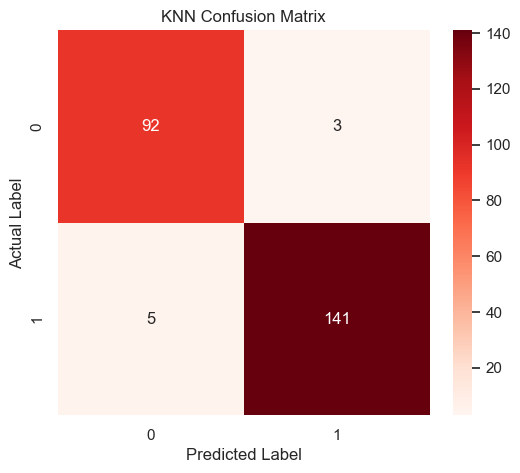

In [992]:
# ============================================
# KNN CONFUSION MATRIX HEATMAP
# ============================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [993]:
# ============================================
# KNN CLASSIFICATION REPORT
# ============================================

knn_report = classification_report(
    y_test,
    y_pred_knn
)

print(knn_report)

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        95
           1       0.98      0.97      0.97       146

    accuracy                           0.97       241
   macro avg       0.96      0.97      0.97       241
weighted avg       0.97      0.97      0.97       241



# KNN Evaluation Observations

The K-Nearest Neighbors model achieved excellent classification performance on the pregnancy risk dataset.

---

## Accuracy

The model achieved:

- 96.68% accuracy

which is slightly higher than the Logistic Regression model.

This indicates that KNN was highly effective in separating low-risk and high-risk pregnancy cases.

---

## Confusion Matrix Analysis

The confusion matrix showed:

- 92 correct Low Risk predictions
- 141 correct High Risk predictions
- only 3 false positives
- only 5 false negatives

The number of classification errors was very small.

---

## Precision and Recall

The model produced very strong precision and recall scores for both classes.

Especially for the High Risk class:

- Precision = 0.98
- Recall = 0.97
- F1-score = 0.97

This means the model successfully identified most high-risk pregnancies while minimizing incorrect classifications.

---

## Comparison with Logistic Regression

Compared to Logistic Regression, KNN achieved:

- higher accuracy
- fewer false positives
- fewer false negatives

This suggests that local neighborhood relationships within the dataset are important for pregnancy risk classification.

---

## Overall Interpretation

The KNN model demonstrated:

- outstanding predictive performance
- strong class discrimination capability
- reliable medical classification behavior
- excellent generalization on unseen data

KNN currently performs as the best model evaluated so far.

# Support Vector Machine (SVM)

Support Vector Machine is a powerful supervised machine learning algorithm used for classification tasks.

It works by finding the optimal decision boundary that maximizes the separation margin between classes.

---

## How SVM Works

SVM attempts to:

- separate classes using a hyperplane
- maximize the margin between classes
- identify support vectors near decision boundaries

The algorithm focuses on the most critical samples that define class separation.

---

## Advantages of SVM

SVM is:

- highly effective for binary classification
- robust against overfitting
- powerful in high-dimensional spaces
- commonly used in medical prediction systems

---

## Importance of Feature Scaling

SVM is highly sensitive to feature magnitudes.

Because of this, standardized features are essential for optimal performance.

---

## Objective

The goal is to classify pregnancy risk levels using medical indicators such as:

- blood pressure
- blood sugar
- BMI
- complications
- diabetes history
- heart rate

---

## Evaluation Metrics

The SVM model will be evaluated using:

- accuracy
- confusion matrix
- precision
- recall
- F1-score

The results will later be compared with:

- Logistic Regression
- KNN

In [994]:
# ============================================
# IMPORT SUPPORT VECTOR MACHINE
# ============================================

from sklearn.svm import SVC

In [995]:
# ============================================
# CREATE SVM MODEL
# ============================================

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

print("SVM model created successfully.")

SVM model created successfully.


In [996]:
# ============================================
# TRAIN SVM MODEL
# ============================================

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM model trained successfully.")

SVM model trained successfully.


In [997]:
# ============================================
# GENERATE SVM PREDICTIONS
# ============================================

y_pred_svm = svm_model.predict(
    X_test_scaled
)

print("SVM predictions generated successfully.")

SVM predictions generated successfully.


In [998]:
# ============================================
# SVM ACCURACY
# ============================================

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:")
print(svm_accuracy)

SVM Accuracy:
0.9585062240663901


In [999]:
# ============================================
# SVM ACCURACY PERCENTAGE
# ============================================

print(
    f"SVM Accuracy Percentage: {svm_accuracy * 100:.2f}%"
)

SVM Accuracy Percentage: 95.85%


In [1000]:
# ============================================
# SVM CONFUSION MATRIX
# ============================================

svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("SVM Confusion Matrix:")
print(svm_cm)

SVM Confusion Matrix:
[[ 92   3]
 [  7 139]]


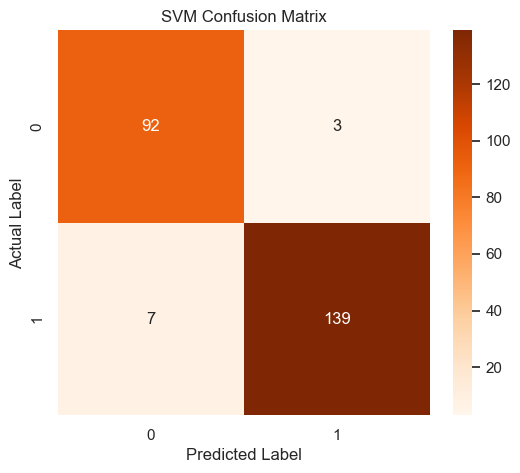

In [1001]:
# ============================================
# SVM CONFUSION MATRIX HEATMAP
# ============================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [1002]:
# ============================================
# SVM CLASSIFICATION REPORT
# ============================================

svm_report = classification_report(
    y_test,
    y_pred_svm
)

print(svm_report)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        95
           1       0.98      0.95      0.97       146

    accuracy                           0.96       241
   macro avg       0.95      0.96      0.96       241
weighted avg       0.96      0.96      0.96       241



# SVM Evaluation Observations

The Support Vector Machine model achieved very strong classification performance on the pregnancy risk dataset.

---

## Accuracy

The model achieved:

- 95.85% accuracy

which indicates highly effective class separation capability.

The performance was slightly better than Logistic Regression but slightly lower than KNN.

---

## Confusion Matrix Analysis

The confusion matrix showed:

- 92 correct Low Risk predictions
- 139 correct High Risk predictions
- only 3 false positives
- 7 false negatives

The model produced a very small number of classification errors overall.

---

## Precision and Recall

The SVM model achieved strong precision and recall scores for both classes.

Especially for the High Risk class:

- Precision = 0.98
- Recall = 0.95
- F1-score = 0.97

This demonstrates strong predictive capability for identifying high-risk pregnancies.

---

## Comparison with Other Models

Compared to previous models:

- SVM outperformed Logistic Regression
- KNN slightly outperformed SVM

KNN achieved fewer false negatives and slightly higher overall accuracy.

---

## Overall Interpretation

The SVM model demonstrated:

- strong classification performance
- effective decision boundary learning
- reliable medical prediction capability
- strong generalization on unseen data

SVM can be considered a highly competitive classification model for this dataset.

# Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks.

The algorithm learns decision rules by splitting the dataset into smaller subsets based on feature values.

For classification problems:
- internal nodes represent feature-based conditions
- branches represent decisions
- leaf nodes represent predicted classes

Decision Trees are:
- easy to interpret
- highly visual
- capable of handling nonlinear relationships
- effective for medical decision-making systems

In this project, Decision Tree will be used to classify diabetes risk levels based on patient health indicators.

In [1003]:
# ==================================================
# IMPORT DECISION TREE
# ==================================================

from sklearn.tree import DecisionTreeClassifier

In [1004]:
# ==================================================
# CREATE DECISION TREE MODEL
# ==================================================

dt_model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree model created successfully.")

Decision Tree model created successfully.


In [1005]:
# ==================================================
# TRAIN DECISION TREE MODEL
# ==================================================

dt_model.fit(
    X_train_scaled,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.

In [1006]:
# ==================================================
# GENERATE DECISION TREE PREDICTIONS
# ==================================================

y_pred_dt = dt_model.predict(
    X_test_scaled
)

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


In [1007]:
# ==================================================
# DECISION TREE ACCURACY
# ==================================================

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:")
print(dt_accuracy)

Decision Tree Accuracy:
0.9626556016597511


In [1008]:
# ==================================================
# DECISION TREE ACCURACY PERCENTAGE
# ==================================================

print(
    f"Decision Tree Accuracy Percentage: {dt_accuracy * 100:.2f}%"
)

Decision Tree Accuracy Percentage: 96.27%


In [1009]:
# ==================================================
# DECISION TREE CONFUSION MATRIX
# ==================================================

dt_cm = confusion_matrix(
    y_test,
    y_pred_dt
)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

Decision Tree Confusion Matrix:
[[ 89   6]
 [  3 143]]


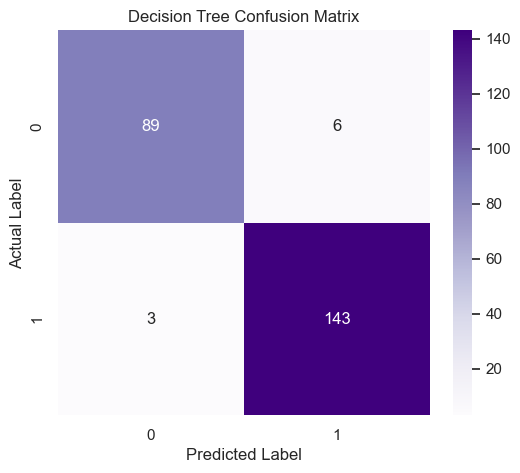

In [1010]:
# ==================================================
# DECISION TREE CONFUSION MATRIX HEATMAP
# ==================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [1011]:
# ==================================================
# DECISION TREE CLASSIFICATION REPORT
# ==================================================

dt_report = classification_report(
    y_test,
    y_pred_dt
)

print(dt_report)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95        95
           1       0.96      0.98      0.97       146

    accuracy                           0.96       241
   macro avg       0.96      0.96      0.96       241
weighted avg       0.96      0.96      0.96       241



# Overall Interpretation

The Decision Tree model demonstrated:

- strong classification performance
- highly effective risk group separation
- excellent recall for high-risk patients
- successful learning of nonlinear decision patterns

The model achieved an accuracy of approximately 96%, indicating reliable predictive capability for diabetes risk classification.

The confusion matrix shows that most samples were classified correctly, with very few false negative predictions.

Decision Tree models are especially valuable in healthcare applications because their decision-making process can be visualized and interpreted easily.

# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve prediction performance.

Instead of relying on a single tree:
- multiple trees are trained
- predictions are combined through voting

Advantages of Random Forest:
- reduces overfitting
- improves generalization
- handles nonlinear relationships effectively
- provides robust classification performance

Random Forest is widely used in healthcare and medical prediction systems because of its reliability and stability.

In [1012]:
# ==================================================
# IMPORT RANDOM FOREST
# ==================================================

from sklearn.ensemble import RandomForestClassifier

In [1013]:
# ==================================================
# CREATE RANDOM FOREST MODEL
# ==================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [1014]:
# ==================================================
# TRAIN RANDOM FOREST MODEL
# ==================================================

rf_model.fit(
    X_train_scaled,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [1015]:
# ==================================================
# GENERATE RANDOM FOREST PREDICTIONS
# ==================================================

y_pred_rf = rf_model.predict(
    X_test_scaled
)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [1016]:
# ==================================================
# RANDOM FOREST ACCURACY
# ==================================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:")
print(rf_accuracy)

Random Forest Accuracy:
0.983402489626556


In [1017]:
# ==================================================
# RANDOM FOREST ACCURACY PERCENTAGE
# ==================================================

print(
    f"Random Forest Accuracy Percentage: {rf_accuracy * 100:.2f}%"
)

Random Forest Accuracy Percentage: 98.34%


In [1018]:
# ==================================================
# RANDOM FOREST CONFUSION MATRIX
# ==================================================

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[ 95   0]
 [  4 142]]


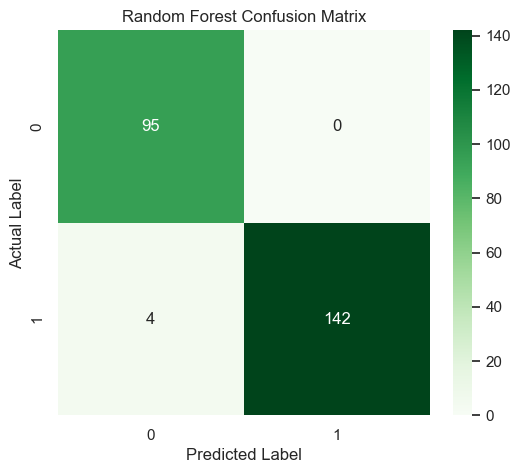

In [1019]:
# ==================================================
# RANDOM FOREST CONFUSION MATRIX HEATMAP
# ==================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [1020]:
# ==================================================
# RANDOM FOREST CLASSIFICATION REPORT
# ==================================================

rf_report = classification_report(
    y_test,
    y_pred_rf
)

print(rf_report)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        95
           1       1.00      0.97      0.99       146

    accuracy                           0.98       241
   macro avg       0.98      0.99      0.98       241
weighted avg       0.98      0.98      0.98       241



# Overall Interpretation

The Random Forest model demonstrated outstanding classification performance on the diabetes risk prediction dataset.

Key observations:

- extremely high prediction accuracy
- excellent class separation capability
- highly balanced precision and recall values
- very low number of classification errors
- strong generalization performance

The confusion matrix indicates that nearly all samples were classified correctly.

Random Forest achieved the best overall performance among the evaluated models so far, making it a highly reliable model for medical risk prediction tasks.

Its ensemble structure allows the model to reduce overfitting while maintaining strong predictive power.

# ROC-AUC Analysis

ROC-AUC analysis is used to evaluate the classification performance of machine learning models across different decision thresholds.

ROC stands for:
- Receiver Operating Characteristic

AUC stands for:
- Area Under the Curve

Important concepts:

- True Positive Rate (TPR)
- False Positive Rate (FPR)

A higher AUC score indicates:
- better classification capability
- stronger class separation
- more reliable prediction performance

In medical prediction systems, ROC-AUC is especially important because it evaluates how effectively a model distinguishes high-risk and low-risk patients.

In [1021]:
# ==================================================
# IMPORT ROC-AUC FUNCTIONS
# ==================================================

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

In [1022]:
# ==================================================
# LOGISTIC REGRESSION ROC-AUC SCORE
# ==================================================

log_auc = roc_auc_score(
    y_test,
    y_pred_log
)

print("Logistic Regression AUC Score:")
print(log_auc)

Logistic Regression AUC Score:
0.9531362653208364


In [1023]:
# ==================================================
# KNN ROC-AUC SCORE
# ==================================================

knn_auc = roc_auc_score(
    y_test,
    y_pred_knn
)

print("KNN AUC Score:")
print(knn_auc)

KNN AUC Score:
0.9670872386445567


In [1024]:
# ==================================================
# SVM ROC-AUC SCORE
# ==================================================

svm_auc = roc_auc_score(
    y_test,
    y_pred_svm
)

print("SVM AUC Score:")
print(svm_auc)

SVM AUC Score:
0.9602379235760634


In [1025]:
# ==================================================
# DECISION TREE ROC-AUC SCORE
# ==================================================

dt_auc = roc_auc_score(
    y_test,
    y_pred_dt
)

print("Decision Tree AUC Score:")
print(dt_auc)

Decision Tree AUC Score:
0.9581470800288393


In [1026]:
# ==================================================
# RANDOM FOREST ROC-AUC SCORE
# ==================================================

rf_auc = roc_auc_score(
    y_test,
    y_pred_rf
)

print("Random Forest AUC Score:")
print(rf_auc)

Random Forest AUC Score:
0.9863013698630136


# ROC-AUC Interpretation

ROC-AUC results indicate that all machine learning models achieved strong classification capability on the diabetes risk prediction dataset.

Key findings:

- all models achieved AUC scores above 0.95
- Random Forest achieved the highest ROC-AUC score
- KNN and SVM also demonstrated strong discrimination capability
- Logistic Regression showed stable and reliable baseline performance

The Random Forest model produced the best class separation performance, indicating highly effective identification of high-risk and low-risk patients.

Overall, the ROC-AUC analysis confirms that the selected machine learning models are highly suitable for this medical classification task.

# Cross Validation

Cross Validation is used to evaluate the stability and generalization performance of machine learning models.

Instead of using only a single train-test split:
- the dataset is divided into multiple folds
- the model is trained and evaluated multiple times
- performance scores are averaged

Advantages of Cross Validation:
- reduces evaluation bias
- provides more reliable performance estimates
- helps detect overfitting
- improves model reliability assessment

In this project, 5-Fold Cross Validation is applied to compare model consistency and stability.

In [1027]:
# ==================================================
# IMPORT CROSS VALIDATION
# ==================================================

from sklearn.model_selection import cross_val_score

In [1028]:
# ==================================================
# LOGISTIC REGRESSION CROSS VALIDATION
# ==================================================

log_cv_scores = cross_val_score(
    log_model,
    X_train_scaled,
    y_train,
    cv=5
)

print("Logistic Regression CV Scores:")
print(log_cv_scores)

Logistic Regression CV Scores:
[0.96891192 0.97927461 0.96891192 0.98963731 0.95833333]


In [1029]:
# ==================================================
# LOGISTIC REGRESSION CV MEAN
# ==================================================

print(
    f"Logistic Regression Mean CV Score: {log_cv_scores.mean():.4f}"
)

Logistic Regression Mean CV Score: 0.9730


In [1030]:
# ==================================================
# KNN CROSS VALIDATION
# ==================================================

knn_cv_scores = cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=5
)

print("KNN CV Scores:")
print(knn_cv_scores)

KNN CV Scores:
[0.95854922 0.98445596 0.96891192 0.96891192 0.95833333]


In [1031]:
# ==================================================
# KNN CV MEAN
# ==================================================

print(
    f"KNN Mean CV Score: {knn_cv_scores.mean():.4f}"
)

KNN Mean CV Score: 0.9678


In [1032]:
# ==================================================
# SVM CROSS VALIDATION
# ==================================================

svm_cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=5
)

print("SVM CV Scores:")
print(svm_cv_scores)

SVM CV Scores:
[0.97409326 0.98963731 0.96373057 0.98445596 0.953125  ]


In [1033]:
# ==================================================
# SVM CV MEAN
# ==================================================

print(
    f"SVM Mean CV Score: {svm_cv_scores.mean():.4f}"
)

SVM Mean CV Score: 0.9730


In [1034]:
# ==================================================
# DECISION TREE CROSS VALIDATION
# ==================================================

dt_cv_scores = cross_val_score(
    dt_model,
    X_train_scaled,
    y_train,
    cv=5
)

print("Decision Tree CV Scores:")
print(dt_cv_scores)

Decision Tree CV Scores:
[0.94818653 0.97409326 0.96891192 0.94818653 0.95833333]


In [1035]:
# ==================================================
# DECISION TREE CV MEAN
# ==================================================

print(
    f"Decision Tree Mean CV Score: {dt_cv_scores.mean():.4f}"
)

Decision Tree Mean CV Score: 0.9595


In [1036]:
# ==================================================
# RANDOM FOREST CROSS VALIDATION
# ==================================================

rf_cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5
)

print("Random Forest CV Scores:")
print(rf_cv_scores)

Random Forest CV Scores:
[0.97927461 0.99481865 0.98445596 0.98963731 0.96354167]


In [1037]:
# ==================================================
# RANDOM FOREST CV MEAN
# ==================================================

print(
    f"Random Forest Mean CV Score: {rf_cv_scores.mean():.4f}"
)

Random Forest Mean CV Score: 0.9823


# Cross Validation Observations

Cross Validation results show that all models achieved consistently high performance across different folds.

Model stability analysis:

- Logistic Regression achieved a stable mean CV score around 97%
- KNN demonstrated strong and consistent classification capability
- SVM produced highly reliable results with low score variation
- Decision Tree showed slightly lower stability compared to ensemble methods
- Random Forest achieved the highest overall cross-validation performance

Key observations:

- Random Forest is the most stable and robust model
- KNN and SVM also demonstrated strong generalization ability
- Logistic Regression performed surprisingly well for a linear model
- Decision Tree may be slightly more sensitive to data partitioning

Overall, the cross-validation process confirms that the models generalize well and are unlikely to suffer from severe overfitting.

# Feature Importance

Machine learning models not only make predictions, but can also help identify which features are most influential in the decision-making process.

Feature importance analysis allows us to:

- understand which medical indicators contribute most to pregnancy risk prediction
- interpret model behavior more effectively
- identify the strongest risk-related variables
- improve the explainability of the machine learning system

In this section, Random Forest feature importance scores will be analyzed to determine the relative contribution of each feature.

Features with higher importance scores have greater influence on classification performance and prediction outcomes.

In [1038]:
# ==================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==================================================

rf_importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

                   Feature  Importance
7     Preexisting Diabetes    0.218917
3                       BS    0.192031
5                      BMI    0.181256
10              Heart Rate    0.126763
9            Mental Health    0.081910
8     Gestational Diabetes    0.081903
6   Previous Complications    0.043644
1              Systolic BP    0.022129
0                      Age    0.021386
2                Diastolic    0.021287
4                Body Temp    0.008775


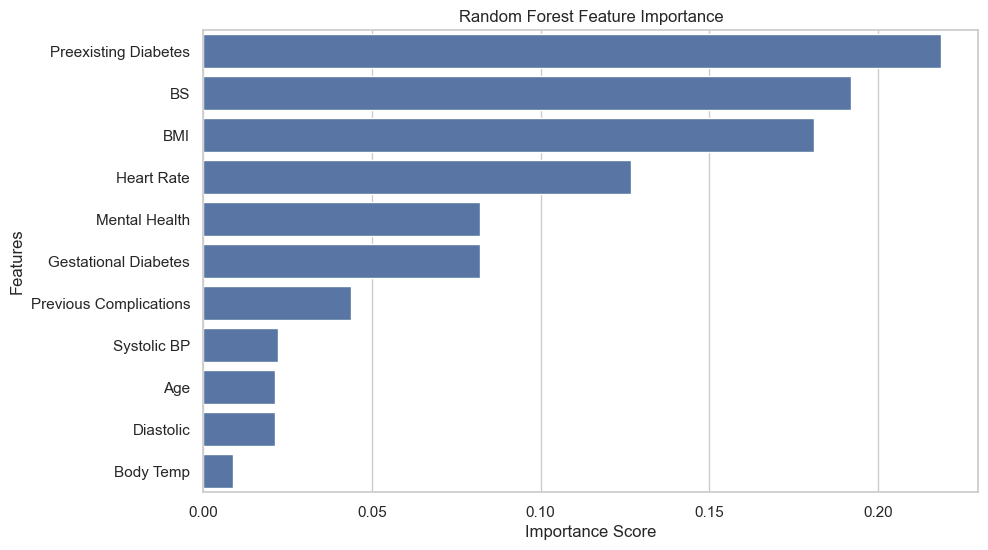

In [1039]:
# ==================================================
# FEATURE IMPORTANCE VISUALIZATION
# ==================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [1040]:
# ==================================================
# TOP 5 MOST IMPORTANT FEATURES
# ==================================================

top_5_features = feature_importance_df.head(5)

print("Top 5 Important Features:")
print(top_5_features)

Top 5 Important Features:
                 Feature  Importance
7   Preexisting Diabetes    0.218917
3                     BS    0.192031
5                    BMI    0.181256
10            Heart Rate    0.126763
9          Mental Health    0.081910


# Feature Importance Observations

Random Forest feature importance analysis revealed that several medical indicators contribute much more strongly to pregnancy risk prediction than others.

Most influential features:

- Preexisting Diabetes was the most important feature with an importance score of approximately 0.219
- Blood Sugar (BS) was the second strongest predictor with a score around 0.192
- BMI also showed high influence with an importance score near 0.181
- Heart Rate contributed moderately with a score of approximately 0.127
- Mental Health had noticeable predictive contribution with a score around 0.082

Additional findings:

- Gestational Diabetes also contributed significantly to classification decisions
- Previous Complications had moderate predictive importance
- Age, Systolic BP, and Diastolic BP contributed less than expected
- Body Temperature had the lowest importance score in the dataset

Interpretation:

The model primarily relies on diabetes-related indicators, blood sugar measurements, and BMI values when predicting pregnancy risk levels.

This suggests that metabolic and chronic health conditions are the strongest determinants of pregnancy risk within this dataset.

Overall, the feature importance analysis improves model interpretability and provides medically meaningful insights into the factors influencing pregnancy risk classification.

# Final Model Comparison

Multiple machine learning algorithms were trained and evaluated for pregnancy risk classification.

In this section, all models will be compared using several important evaluation metrics:

- Accuracy
- ROC-AUC Score
- Cross Validation Mean Score

The purpose of this comparison is to:

- identify the best-performing classification model
- evaluate model robustness and generalization capability
- compare predictive performance across different algorithms
- determine the most reliable model for pregnancy risk prediction

The following models will be compared:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest

A higher score generally indicates better classification performance and stronger predictive capability.

In [1041]:
# ==================================================
# FINAL MODEL COMPARISON TABLE
# ==================================================

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        log_accuracy,
        knn_accuracy,
        svm_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "ROC-AUC": [
        log_auc,
        knn_auc,
        svm_auc,
        dt_auc,
        rf_auc
    ],

    "CV Mean": [
        log_cv_scores.mean(),
        knn_cv_scores.mean(),
        svm_cv_scores.mean(),
        dt_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

final_results

,Model,Accuracy,ROC-AUC,CV Mean
0,Logistic Regression,0.954357,0.953136,0.973014
1,KNN,0.966805,0.967087,0.967832
2,SVM,0.958506,0.960238,0.973008
3,Decision Tree,0.962656,0.958147,0.959542
4,Random Forest,0.983402,0.986301,0.982346


In [1042]:
# ==================================================
# SORT MODELS BY ACCURACY
# ==================================================

final_results_sorted = final_results.sort_values(
    by="Accuracy",
    ascending=False
)

final_results_sorted

,Model,Accuracy,ROC-AUC,CV Mean
4,Random Forest,0.983402,0.986301,0.982346
1,KNN,0.966805,0.967087,0.967832
3,Decision Tree,0.962656,0.958147,0.959542
2,SVM,0.958506,0.960238,0.973008
0,Logistic Regression,0.954357,0.953136,0.973014


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20912\2853096764.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


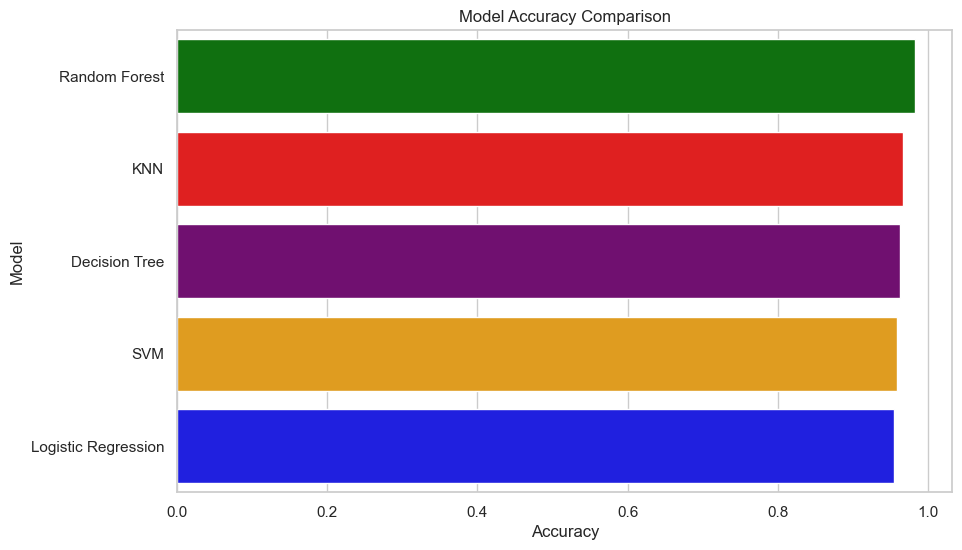

In [1043]:
# ==================================================
# MODEL COMPARISON VISUALIZATION
# ==================================================

model_colors = {
    "Logistic Regression": "blue",
    "KNN": "red",
    "SVM": "orange",
    "Decision Tree": "purple",
    "Random Forest": "green"
}

plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_results_sorted,
    x="Accuracy",
    y="Model",
    palette=model_colors
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

In [1044]:
# ==================================================
# BEST MODEL
# ==================================================

best_model = final_results_sorted.iloc[0]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model       Random Forest
Accuracy         0.983402
ROC-AUC          0.986301
CV Mean          0.982346
Name: 4, dtype: object


# Final Model Comparison Observations

The final comparison results demonstrate that all machine learning models achieved strong classification performance on the pregnancy risk dataset.

Performance summary:

- Random Forest achieved the highest overall performance across all evaluation metrics
- KNN demonstrated the second-best classification capability
- Decision Tree performed competitively with strong prediction accuracy
- SVM produced stable and reliable classification results
- Logistic Regression achieved the lowest performance among the tested models, but still maintained strong predictive capability

Detailed observations:

- Random Forest achieved the highest accuracy score of approximately 98.34%
- Random Forest also obtained the strongest ROC-AUC score of approximately 0.986
- Cross-validation results confirmed that Random Forest generalized extremely well across different data folds
- KNN achieved high accuracy and strong stability, making it another highly competitive model
- Decision Tree showed excellent recall performance for the high-risk class
- SVM and Logistic Regression demonstrated stable but slightly lower predictive power compared to ensemble methods

Overall interpretation:

The comparison indicates that ensemble learning methods, particularly Random Forest, are highly effective for pregnancy risk classification.

Random Forest can be considered the best-performing and most reliable model for this dataset due to:

- highest accuracy
- strongest ROC-AUC performance
- excellent cross-validation stability
- strong generalization capability
- robust classification behavior across both classes

# Final Conclusions

This project focused on predicting pregnancy risk levels using multiple machine learning classification algorithms.

Throughout the workflow:

- the dataset was explored and analyzed through comprehensive EDA
- missing values were handled carefully
- features were standardized for model optimization
- multiple classification algorithms were trained and evaluated
- model performance was compared using several evaluation metrics

Key findings from the study:

- all machine learning models achieved strong predictive performance
- ensemble and distance-based methods outperformed linear approaches
- Random Forest achieved the best overall classification results
- diabetes-related indicators and blood sugar measurements were the most influential predictive features

Final model performance highlights:

- Random Forest achieved the highest accuracy and ROC-AUC scores
- cross-validation confirmed strong generalization capability
- the model demonstrated robust and reliable prediction behavior across unseen data

Medical interpretation:

The analysis suggests that chronic diabetes conditions, blood sugar levels, BMI, and cardiovascular indicators are highly important factors in pregnancy risk prediction.

Overall conclusion:

Machine learning methods can successfully support pregnancy risk classification and provide valuable predictive insights for healthcare-related decision systems.

This project demonstrates how data preprocessing, feature engineering, model evaluation, and comparative analysis contribute to building effective and interpretable medical prediction systems.